# UMAP Embeddings of EEG Feature Vectors — Subject 9

Compare how CAR and Euclidean Alignment (EA) change the geometry of the feature space.
Four conditions: raw, CAR only, EA only, CAR + EA.
Windows coloured by horizon label (1 = press within 1000 ms, 0 = resting).

## 1 · Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from umap import UMAP

sys.path.insert(0, "..")
from src.preprocessing import load_trial, build_windows, make_horizon_labels, euclidean_align

print("Imports OK.")

Imports OK.


## 2 · Config

In [2]:
SUBJECT    = 9
TACHE      = "spt"
FS, DECIM  = 250, 4
FS_EFF     = FS // DECIM
LP, HP     = 0.5, 30.0
HORIZON    = int(1.0 * FS_EFF)   # 1000 ms
T          = int(1.0 * FS_EFF)   # window length = 1000 ms
DATA_PATH  = f"../data/subject{SUBJECT}/"
N_UMAP     = 8_000               # subsample for UMAP speed
RANDOM     = 42

import glob
def available_trials(subj):
    files = glob.glob(f"../data/subject{subj}/subject_{subj}_tache_spt_trial_*.csv")
    return sorted(int(f.split("trial_")[1].replace(".csv","")) for f in files)

ALL_TRIALS = available_trials(SUBJECT)
print(f"Subject {SUBJECT}: {len(ALL_TRIALS)} trials — {ALL_TRIALS}")
print(f"T = {T} samples ({T/FS_EFF*1000:.0f} ms)  HORIZON = {HORIZON} samples")

Subject 9: 10 trials — [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
T = 62 samples (1000 ms)  HORIZON = 62 samples


## 3 · Load features under 4 conditions

In [3]:
def load_features(car: bool, ea: bool):
    """Load all trials, build windows, optionally apply CAR and/or EA.
    Returns X_flat (N, T*C), y (N,).
    """
    EEG_COLS = None
    Xw_parts, yw_parts = [], []

    for t in ALL_TRIALS:
        df, cols = load_trial(SUBJECT, TACHE, t, DATA_PATH,
                              eeg_cols=EEG_COLS, lp=LP, hp=HP,
                              decimate=DECIM, car=car, trial_zscore=True)
        if EEG_COLS is None:
            EEG_COLS = cols
        X_t = df[EEG_COLS].values.astype(np.float32)
        y_t = make_horizon_labels(df["button"].values.astype(int), HORIZON)
        Xw, yw = build_windows(X_t, y_t, T, per_window_norm=False)
        Xw_parts.append(Xw.reshape(-1, T, len(EEG_COLS)))
        yw_parts.append(yw)

    X3d = np.concatenate(Xw_parts)   # (N, T, C)
    y   = np.concatenate(yw_parts)

    if ea:
        X3d, _ = euclidean_align(X3d)

    # per-window z-score then flatten
    mu = X3d.mean(axis=1, keepdims=True)
    sd = X3d.std(axis=1, keepdims=True) + 1e-8
    X_flat = ((X3d - mu) / sd).reshape(len(y), -1).astype(np.float32)

    return X_flat, y

CONDITIONS = [
    (False, False, "No CAR · No EA"),
    (True,  False, "CAR · No EA"),
    (False, True,  "No CAR · EA"),
    (True,  True,  "CAR + EA"),
]

datasets = {}
for car, ea, label in CONDITIONS:
    X, y = load_features(car, ea)
    datasets[label] = (X, y)
    pos = y.mean() * 100
    print(f"  {label:20s}: {len(y):,} windows  {pos:.1f}% press")

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
-

## 4 · Subsample & fit UMAP

In [4]:
rng = np.random.default_rng(RANDOM)

embeddings = {}
for label, (X, y) in datasets.items():
    n = min(N_UMAP, len(y))
    idx = rng.choice(len(y), n, replace=False)
    Xs, ys = X[idx], y[idx]

    reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                   metric="euclidean", random_state=RANDOM, verbose=False)
    emb = reducer.fit_transform(Xs)
    embeddings[label] = (emb, ys)
    print(f"  {label:20s}: UMAP done  shape={emb.shape}")

print("All embeddings computed.")

  No CAR · No EA      : UMAP done  shape=(8000, 2)
  CAR · No EA         : UMAP done  shape=(8000, 2)
  No CAR · EA         : UMAP done  shape=(8000, 2)
  CAR + EA            : UMAP done  shape=(8000, 2)
All embeddings computed.


## 5 · Plot

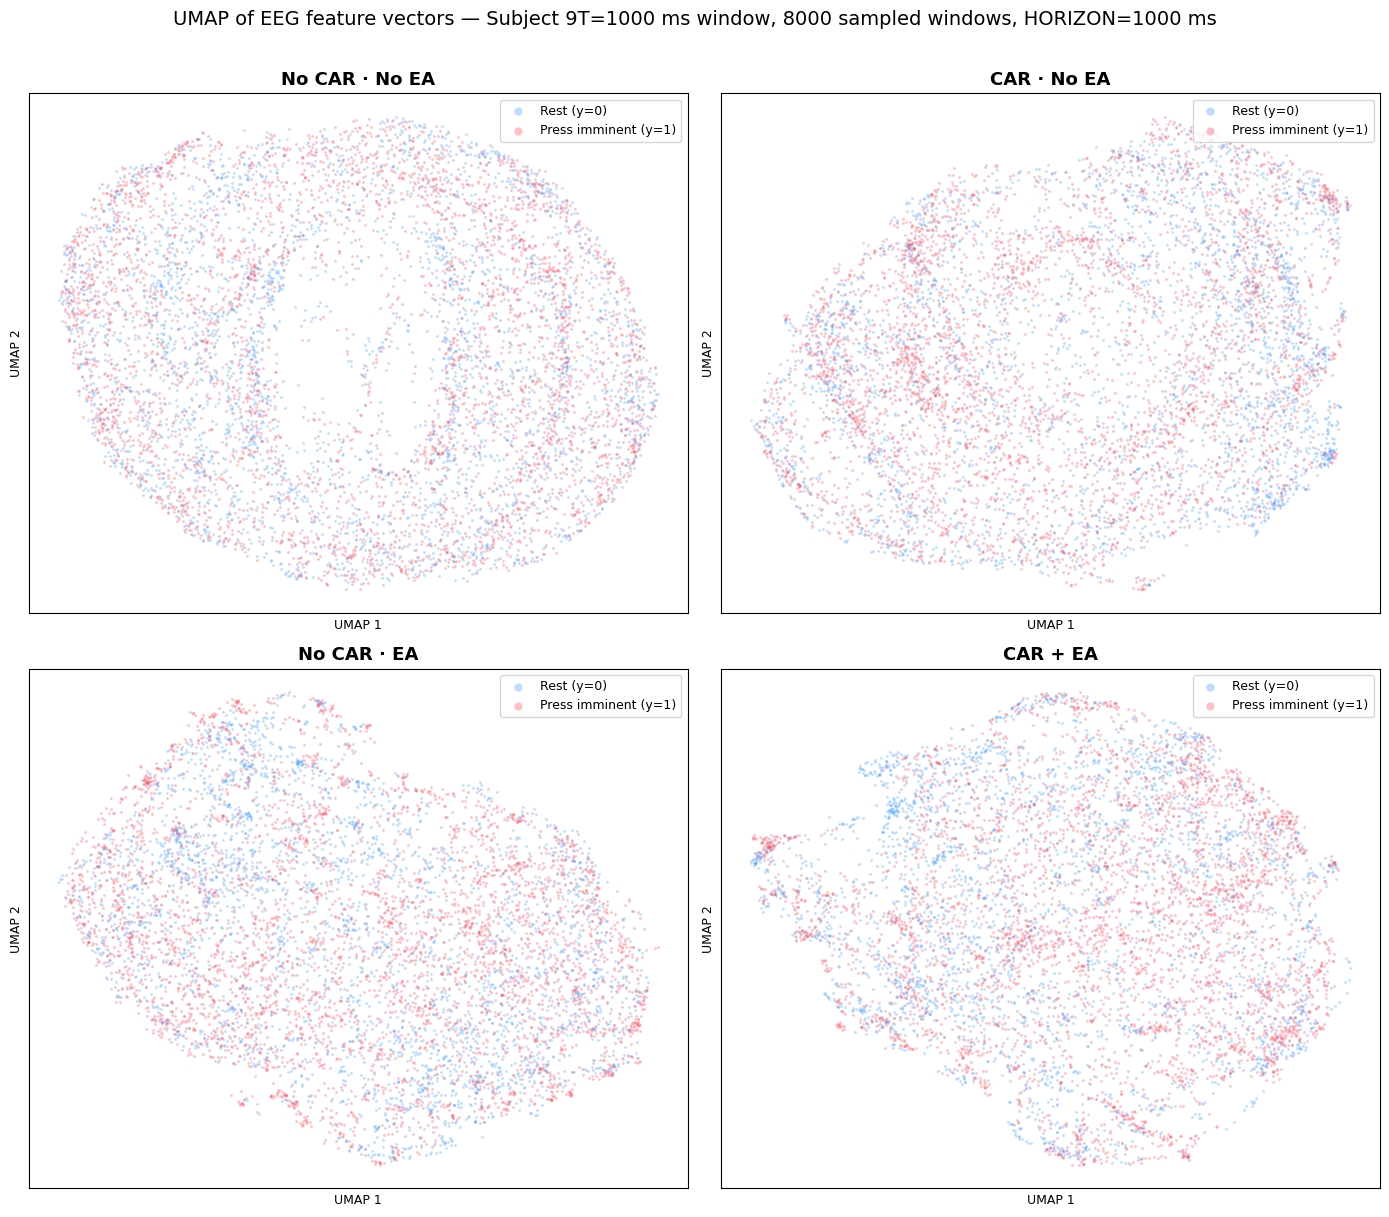

Saved: report/umap_subject9.png


In [5]:
%matplotlib inline

COLORS = {0: "#4a9eff", 1: "#ff4f5e"}
LABELS = {0: "Rest (y=0)", 1: "Press imminent (y=1)"}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (label, (emb, ys)) in zip(axes, embeddings.items()):
    for cls in [0, 1]:
        mask = ys == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=COLORS[cls], label=LABELS[cls],
                   s=4, alpha=0.35, linewidths=0, rasterized=True)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("UMAP 1", fontsize=9)
    ax.set_ylabel("UMAP 2", fontsize=9)
    ax.legend(markerscale=3, fontsize=9, loc="upper right")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    f"UMAP of EEG feature vectors — Subject {SUBJECT}"
    f"T={T/FS_EFF*1000:.0f} ms window, {N_UMAP} sampled windows, HORIZON={HORIZON/FS_EFF*1000:.0f} ms",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig("report/umap_subject9.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report/umap_subject9.png")

## 6 · Colour by trial (bonus — check trial-level clustering)

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
-

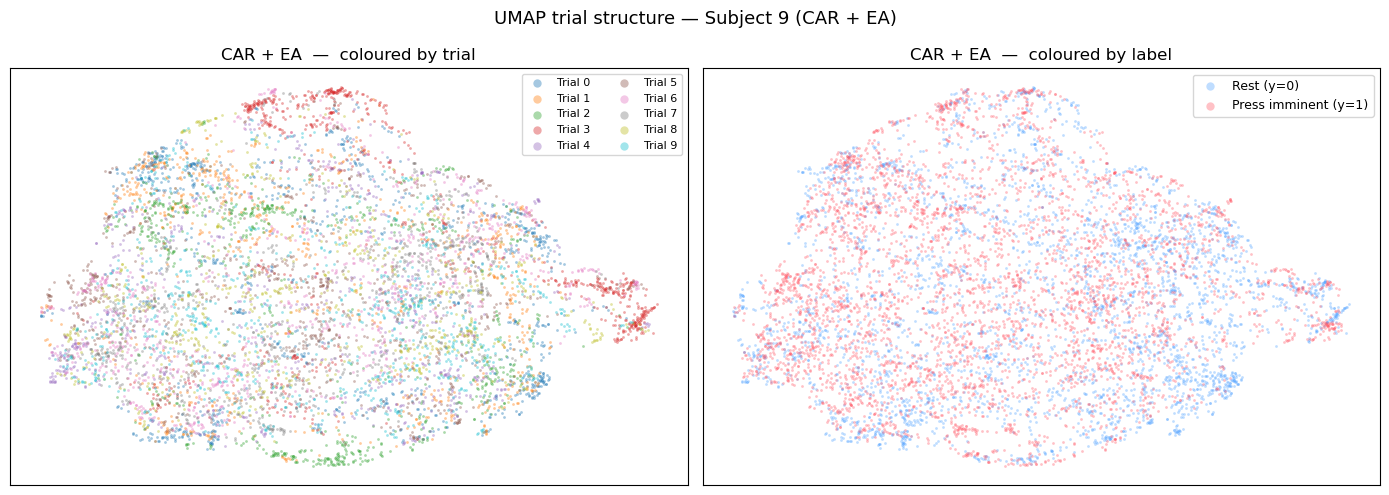

Saved: report/umap_subject9_trials.png


In [6]:
%matplotlib inline
import matplotlib.cm as cm

# Use CAR+EA condition for the trial colouring
X_ce, y_ce = datasets["CAR + EA"]
rng2 = np.random.default_rng(RANDOM + 1)
n = min(N_UMAP, len(y_ce))
idx2 = rng2.choice(len(y_ce), n, replace=False)

# rebuild trial ids for this condition
EEG_COLS2 = None
tid_parts = []
for t in ALL_TRIALS:
    df, cols = load_trial(SUBJECT, TACHE, t, DATA_PATH,
                          eeg_cols=EEG_COLS2, lp=LP, hp=HP,
                          decimate=DECIM, car=True)
    if EEG_COLS2 is None:
        EEG_COLS2 = cols
    X_t = df[EEG_COLS2].values.astype(np.float32)
    y_t = make_horizon_labels(df["button"].values.astype(int), HORIZON)
    _, yw = build_windows(X_t, y_t, T, per_window_norm=False)
    tid_parts.append(np.full(len(yw), t, dtype=np.int32))
tids = np.concatenate(tid_parts)

reducer2 = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                metric="euclidean", random_state=RANDOM, verbose=False)
emb2 = reducer2.fit_transform(X_ce[idx2])
tids_s = tids[idx2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coloured by trial
ax = axes[0]
cmap_t = cm.get_cmap("tab10", len(ALL_TRIALS))
for i, t in enumerate(ALL_TRIALS):
    m = tids_s == t
    ax.scatter(emb2[m, 0], emb2[m, 1], c=[cmap_t(i)],
               s=4, alpha=0.4, label=f"Trial {t}", linewidths=0, rasterized=True)
ax.set_title("CAR + EA  —  coloured by trial", fontsize=12)
ax.legend(markerscale=3, fontsize=8, ncol=2, loc="upper right")
ax.set_xticks([]); ax.set_yticks([])

# Right: coloured by label
ax = axes[1]
for cls in [0, 1]:
    m = y_ce[idx2] == cls
    ax.scatter(emb2[m, 0], emb2[m, 1], c=COLORS[cls],
               s=4, alpha=0.35, label=LABELS[cls], linewidths=0, rasterized=True)
ax.set_title("CAR + EA  —  coloured by label", fontsize=12)
ax.legend(markerscale=3, fontsize=9, loc="upper right")
ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"UMAP trial structure — Subject {SUBJECT} (CAR + EA)", fontsize=13)
plt.tight_layout()
plt.savefig("report/umap_subject9_trials.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report/umap_subject9_trials.png")